# **MultiModal RAG App for Video Processing With LlamaIndex and LanceDB**

### 1. llamaindex framework
### 2. Lancedb Vector DataBase
### 3. LLM MultiModAl GPT-4V or Google-gemini-pro-vision


# **Steps Need to follow:**
#### 1. Download video from YouTube, process and store it.

#### 2. Build Multi-Modal index and vector store for both texts and images.

#### 3. Retrieve relevant images and context, use both to augment the prompt.

#### 4. Using GPT4V for reasoning the correlations between the input query and augmented data and generating final response.

In [87]:
pip install nest_asyncio

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [88]:
import nest_asyncio
nest_asyncio.apply()

In [ ]:
%pip install llama-index-vector-stores-lancedb
%pip install llama-index-multi-modal-llms-openai
%pip install llama-index-embeddings-clip
%pip install git+https://github.com/openai/CLIP.git
!pip install llama-index-readers-file

In [ ]:
%pip install llama-index
%pip install llama-index-llms-gemini
%pip install llama-index-llms-google-genai # multimodal gemini model creation
%pip install llama-index-embeddings-gemini
%pip install google-generativeai
%pip install -U openai-whisper

In [ ]:
%pip install lancedb
%pip install moviepy
%pip install pytube
%pip install yt-dlp
%pip install ffmpeg
%pip install SpeechRecognition
%pip install ffmpeg-python
%pip install soundfile
%pip install torch torchvision
%pip install matplotlib scikit-image
%pip install ftfy regex tqdm

ffmpeg-library enables you to use FFmpeg in Python to manipulate various media files for different purposes like building comprehensive multimedia applications, preprocessing media files.

MoviePy is a Python library for video editing, enabling cutting, concatenations, title insertions, video compositing, and effects like animations or color grading.

Pytube is a Python library used for downloading videos from YouTube. It supports downloading in various formats, resolutions, and also direct audio extraction.


Pydub is a Python library for audio manipulation, enabling easy loading,
editing, and exporting of audio files in various formats with minimal code.

The SpeechRecognition library in Python allows you to convert spoken language into text using various engines and APIs, such as Google Speech Recognition, IBM Speech to Text, etc.


SoundFile is a Python library for reading from and writing to audio files, supporting many formats through the libsndfile library, ideal for high-quality audio processing.

FTFY (Fix Text For You) is a Python library that fixes broken Unicode text and mojibake (garbled text due to encoding issues), making text legible again.

OpenAI Whisper is a robust, multilingual speech recognition model developed by OpenAI. It converts speech into text and supports various languages with high accuracy.

pprint is a Python module that provides a capability to "pretty-print" complex data structures in a well-formatted and more readable way than the basic print function.

In [1]:
from moviepy import VideoFileClip
from pathlib import Path
import speech_recognition as sr
from pytube import YouTube
from pprint import pprint
from PIL import Image
import matplotlib.pyplot as plt

In [2]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [3]:
google_api_key = os.getenv("GOOGLE_API_KEY")

if google_api_key == "":
    print('api key noy found')

In [2]:
import os
print(os.getcwd())

E:\genai\10_multimodal_rag


In [3]:
video_url="https://youtu.be/3dhcmeOTZ_Q"

In [7]:
output_video_path = "content/video_data/"

In [8]:
# from the video i am going to collect images,audio,text
output_folder = "content/mixed_data/"
output_audio_path = "content/mixed_data/output_audio.wav"

In [92]:
os.makedirs("content/video_data", exist_ok=True)
os.makedirs("content/mixed_data", exist_ok=True)

In [11]:
filepath=output_video_path + "input_vid.mp4"
print(filepath)

content/video_data/input_vid.mp4


In [13]:
import yt_dlp
import os

def download_video_yt(url, output_path):

    # ensure directory exists
    os.makedirs("content/video_data", exist_ok=True)

    ydl_opts = {
        "outtmpl": os.path.join(output_path, "input_vid.%(ext)s")
    }

    with yt_dlp.YoutubeDL(ydl_opts) as ydl:
        info = ydl.extract_info(url, download=True)

        metadata = {
            "Author": info.get("channel"),
            "Title": info.get("title"),
            "Views": info.get("view_count")
        }

    return metadata

In [14]:
from moviepy import VideoFileClip
def video_to_images(video_path,output_folder):
  clip=VideoFileClip(video_path)
  clip.write_images_sequence(
      os.path.join(output_folder,"frame%04d.png"),fps=0.2
  )

In [15]:
def video_to_audio(video_path,output_audio_path):
  clip=VideoFileClip(video_path)
  audio=clip.audio
  audio.write_audiofile(output_audio_path)

In [16]:
def audio_to_text(audio_path):
  recognizer=sr.Recognizer() # create recognizer object
  audio=sr.AudioFile(audio_path) # Load the audio file

  with audio as source: # Open audio → process → close automatically
    audio_data=recognizer.record(source) # record the audio

    try:

      #recognize the speech
      text = recognizer.recognize_whisper(audio_data) # This sends the audio to local installation OpenAI Whisper speech-to-text model.

    except sr.UnknownValueError:
      print("Speech recognition could not understand the audio.")
  return text

In [17]:
video_url

'https://youtu.be/3dhcmeOTZ_Q'

In [18]:
output_video_path

'content/video_data/'

In [24]:
metadata_vid = download_video_yt(video_url, output_video_path)

[youtube] Extracting URL: https://youtu.be/3dhcmeOTZ_Q
[youtube] 3dhcmeOTZ_Q: Downloading webpage


[youtube] 3dhcmeOTZ_Q: Downloading android vr player API JSON


[info] 3dhcmeOTZ_Q: Downloading 1 format(s): 18
[download] Destination: content\video_data\input_vid.mp4
[download] 100% of    5.94MiB in 00:00:02 at 2.41MiB/s   


In [25]:
metadata_vid

{'Author': '3-Minute Data Science',
 'Title': 'Linear Regression in 3 Minutes',
 'Views': 260103}

In [27]:
video_to_images(filepath,output_folder)


t: 100%|██████████████████████████████████████████████████████████| 47/47 [00:07<00:00,  5.75it/s, now=None]
                                                                                                            

In [28]:
filepath

'content/video_data/input_vid.mp4'

In [29]:
output_audio_path

'content/mixed_data/output_audio.wav'

In [30]:
video_to_audio(filepath,output_audio_path)

t:   2%|█▎                                                         | 1/47 [01:00<46:17, 60.38s/it, now=None]

MoviePy - Writing audio in content/mixed_data/output_audio.wav



t:   2%|█▎                                                         | 1/47 [01:03<48:55, 63.81s/it, now=None]

MoviePy - Done.


In [31]:
text_data=audio_to_text(output_audio_path)


  0%|                                               | 0.00/139M [00:00<?, ?iB/s]
  0%|                                       | 48.0k/139M [00:00<09:08, 265kiB/s]
  0%|                                        | 112k/139M [00:00<05:36, 431kiB/s]
  0%|                                        | 256k/139M [00:00<02:57, 818kiB/s]
  0%|                                       | 400k/139M [00:00<02:19, 1.04MiB/s]
  1%|▏                                      | 784k/139M [00:00<01:12, 2.00MiB/s]
  1%|▍                                     | 1.47M/139M [00:00<00:38, 3.72MiB/s]
  2%|▌                                     | 2.14M/139M [00:00<00:30, 4.69MiB/s]
  3%|█▎                                    | 4.62M/139M [00:00<00:12, 11.2MiB/s]
  6%|██                                    | 7.72M/139M [00:01<00:07, 17.7MiB/s]
  7%|██▌                                   | 9.45M/139M [00:01<00:16, 8.24MiB/s]
  9%|███▎                                  | 12.2M/139M [00:01<00:11, 11.7MiB/s]
 10%|███▊                  

In [32]:
text_data

" When you regression, as a statistical technique for modeling the relationship between an output variable and one or more input variables, in layman's terms, think of it as fitting a line through some data points as shown here so you can make predictions on unknown data, assuming there is a linear relationship between the variables. You might be familiar with the linear function y equals mx plus b, where y is the output variable, also called the dependent variable. You may also see expressed as f of x, the function of the input variable. x on the other hand would serve as the input variable, also called the independent variable. It's likely you'll see the coefficients m and b expressed as beta 1 and beta 0 respectively. So what do the m and b coefficients do? The m or beta 1 coefficient controls the slope of the line, the b or the beta 0 controls the intercept of the line, in machine learning we also know it as the bias. These two coefficients are what we are solving for in linear reg

In [33]:
with open(output_folder + "output_text.txt", "w") as file:
        file.write(text_data)
print("Text data saved to file")
file.close()

Text data saved to file


In [34]:
os.remove(output_audio_path)
print("Audio file removed")

Audio file removed


In [35]:
#process the video
#image
#text

In [51]:
from llama_index.core.indices import MultiModalVectorStoreIndex
from llama_index.core import SimpleDirectoryReader 
from llama_index.core import StorageContext,Settings

In [37]:
from llama_index.vector_stores.lancedb import LanceDBVectorStore

In [38]:
text_store=LanceDBVectorStore(uri="lancedb",table_name="text_collection")
image_store=LanceDBVectorStore(uri="lancedb",table_name="image_collection")

Table text_collection doesn't exist yet. Please add some data to create it.
Table image_collection doesn't exist yet. Please add some data to create it.


In [39]:
storage_context=StorageContext.from_defaults(vector_store=text_store,image_store=image_store)

In [40]:
output_folder

'content/mixed_data/'

In [41]:
documents=SimpleDirectoryReader(output_folder).load_data()

In [48]:
from llama_index.llms.gemini import Gemini
import google.generativeai as genai
from llama_index.embeddings.gemini import GeminiEmbedding

E:\genai\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
E:\genai\venv\Lib\site-packages\llama_index\llms\gemini\base.py:21: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  import google.generativeai as genai


In [85]:
from llama_index.llms.google_genai import GoogleGenAI

model = GoogleGenAI(
    model="gemini-2.5-flash",
    api_key=google_api_key
)

2026-03-28 00:59:17,757 - INFO - HTTP Request: GET https://generativelanguage.googleapis.com/v1beta/models/gemini-2.5-flash "HTTP/1.1 200 OK"


In [54]:
from llama_index.embeddings.clip import ClipEmbedding

embed_model = ClipEmbedding(model_name="ViT-B/32")

In [56]:
Settings.llm = model
Settings.embed_model = embed_model

In [59]:
from llama_index.core.node_parser import SentenceSplitter

splitter = SentenceSplitter(chunk_size=70, chunk_overlap=10)
nodes = splitter.get_nodes_from_documents(documents)

Metadata length (24) is close to chunk size (70). Resulting chunks are less than 50 tokens. Consider increasing the chunk size or decreasing the size of your metadata to avoid this.
Metadata length (24) is close to chunk size (70). Resulting chunks are less than 50 tokens. Consider increasing the chunk size or decreasing the size of your metadata to avoid this.
Metadata length (24) is close to chunk size (70). Resulting chunks are less than 50 tokens. Consider increasing the chunk size or decreasing the size of your metadata to avoid this.
Metadata length (24) is close to chunk size (70). Resulting chunks are less than 50 tokens. Consider increasing the chunk size or decreasing the size of your metadata to avoid this.
Metadata length (24) is close to chunk size (70). Resulting chunks are less than 50 tokens. Consider increasing the chunk size or decreasing the size of your metadata to avoid this.
Metadata length (24) is close to chunk size (70). Resulting chunks are less than 50 tokens

In [ ]:
index = MultiModalVectorStoreIndex(
    nodes,
    storage_context=storage_context
)

In [61]:
retriever_engine=index.as_retriever(similarity_top_k=1, image_similarity_top_k=5)

In [62]:
from llama_index.core.response.notebook_utils import display_source_node
from llama_index.core.schema import ImageNode

In [63]:
def retrieve(retriever_engine, query_str):
    retrieval_results = retriever_engine.retrieve(query_str)

    retrieved_image = []
    retrieved_text = []
    for res_node in retrieval_results:
        if isinstance(res_node.node, ImageNode):
            retrieved_image.append(res_node.node.metadata["file_path"])
        else:
            display_source_node(res_node, source_length=200)
            retrieved_text.append(res_node.text)

    return retrieved_image, retrieved_text

In [64]:
query="can you tell me what is linear regression? explain equation of the multiple linear regression?"

In [65]:
img,text = retrieve(retriever_engine,query)

2026-03-28 00:47:17,259 - INFO - query_type :, vector
2026-03-28 00:47:17,574 - INFO - query_type :, vector


**Node ID:** 830142f5-0bf7-4fe1-a9df-be354280311a<br>**Similarity:** 6.636732396286815e-12<br>**Text:** These two coefficients are what we are solving for in linear regression.<br>

In [78]:
import matplotlib.pyplot as plt
def plot_images(images_path):
  images_shown = 0
  plt.figure(figsize=(16, 9))
  for img_path in images_path:
        if os.path.isfile(img_path):
            image = Image.open(img_path)

            plt.subplot(2, 3, images_shown + 1)
            plt.imshow(image)
            plt.xticks([])
            plt.yticks([])

            images_shown += 1
            # if images_shown >= 5:
            #     break

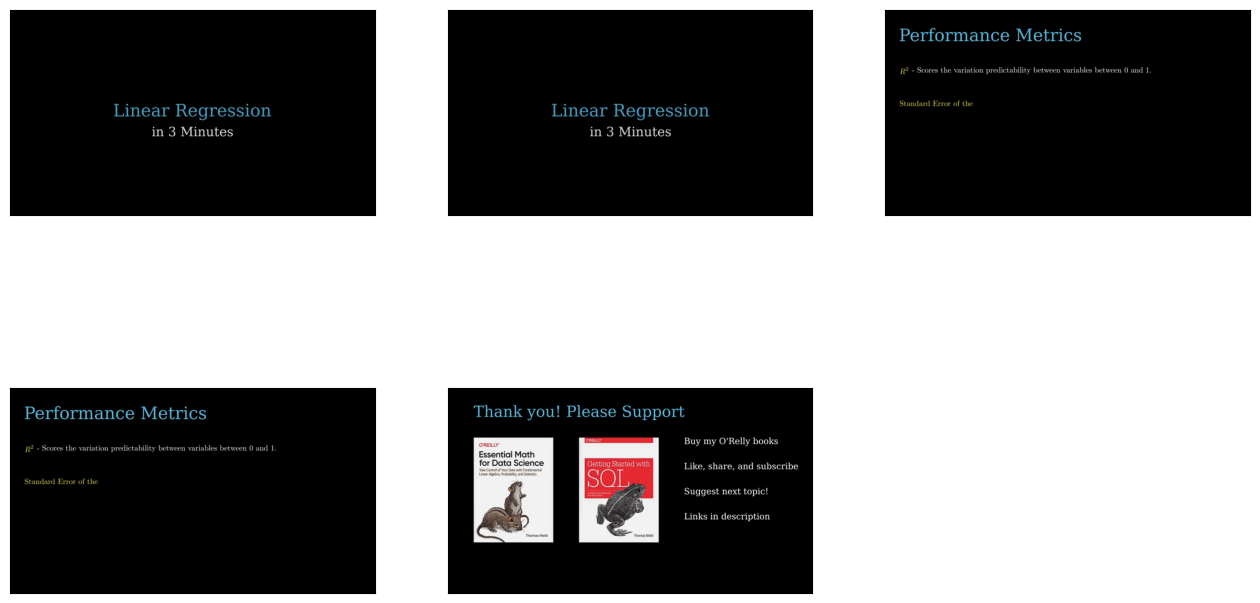

In [79]:
plot_images(img)

In [68]:
qa_tmpl_str=(
    "Based on the provided information, including relevant images and retrieved context from the video, \
    accurately and precisely answer the query without any additional prior knowledge.\n"

    "---------------------\n"
    "Context: {context_str}\n"
    "Metadata for video: {metadata_str} \n"

    "---------------------\n"
    "Query: {query_str}\n"
    "Answer: "
)

In [69]:
img

['E:\\genai\\10_multimodal_rag\\content\\mixed_data\\frame0003.png',
 'E:\\genai\\10_multimodal_rag\\content\\mixed_data\\frame0003.png',
 'E:\\genai\\10_multimodal_rag\\content\\mixed_data\\frame0038.png',
 'E:\\genai\\10_multimodal_rag\\content\\mixed_data\\frame0038.png',
 'E:\\genai\\10_multimodal_rag\\content\\mixed_data\\frame0042.png']

In [70]:
import json
metadata_str=json.dumps(metadata_vid)

In [71]:
query_str="can you tell me what is linear regression and equation of linear regression?"

In [72]:
context_str = "".join(text)

In [73]:
image_documents = SimpleDirectoryReader( input_files=img).load_data()

In [74]:
from llama_index.multi_modal_llms.openai import OpenAIMultiModal

In [89]:
result = model.complete(
    prompt=qa_tmpl_str.format(
        query_str=query_str,
        metadata_str=metadata_str,
        context_str=context_str
    ),
    image_documents=image_documents,
)

2026-03-28 01:00:44,749 - INFO - AFC is enabled with max remote calls: 10.
2026-03-28 01:00:48,489 - INFO - HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-2.5-flash:generateContent "HTTP/1.1 200 OK"


In [90]:
pprint(result.text)

('Based on the provided information, linear regression is a process where we '
 'solve for two coefficients. The provided context does not define what linear '
 'regression is beyond this, nor does it provide the equation of linear '
 'regression.')
